In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import xarray as xr
import cmcrameri.cm as cmc
from matplotlib.colors import LinearSegmentedColormap

plt.style.use('../plotstyling.mplstyle')

In [2]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [4]:
Latitude = ds.Latitude.values
lat_mask = np.where(np.abs(Latitude) < 30)[0]

Fwp = ds.Fwp.values[lat_mask]
Fwc = ds.Fwc.values
TCWV = ds.H2O_Column.values
Zm = ds.Fwp_Zm.values[lat_mask] / 1000

Longitude = ds.Longitude.values
Surf_z = ds.Surf_Z.values
altitude = ds.vertical_level.values / 1000
altitude_in_m = ds.vertical_level.values


channels = ["AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]
channels_diffs = ["21-31", "31-32", "32-33", "33-34", "34-35", "35-36", "36-44", "44-43", "43-42", "42-41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

CS_array = np.zeros((Latitude[lat_mask].shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array[:,i] = ds[f"Ta_Clearsky_{ch}"].values[lat_mask] - ds[f"Ta_Allsky_{ch}"].values[lat_mask]



In [5]:

NEDeltaT = np.array([0.36, 0.50, 0.56, 0.79, 0.84, 1.0, 1.6, 1.53, 0.95, 0.80])
S_epsilon_CS = np.diag(NEDeltaT**2)

FWP_bins = np.logspace(-4, 1, num=21)
Zm_bins  = np.linspace(0, 15, 16)       # 0–15 km, 1 km intervals
WV_bins = np.linspace(0, 70, 22)

def calculate_DoF(measurements, S_epsilon):
    if measurements.shape[0] <= 1:
        return np.nan
    S_y = np.cov(measurements.T)
    eigvals, eigvecs = np.linalg.eigh(S_y)
    idx = eigvals.argsort()[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    S_Lambda = eigvecs @ S_epsilon @ eigvecs.T
    return np.sum(eigvals > np.diag(S_Lambda))



In [6]:

x_var = "Zm"

if x_var == "Zm":
    x_data   = Zm
    x_bins   = Zm_bins
    x_label  = r"Z$_{m}$ [km]"
    x_stride = 2
elif x_var == "Tcwv":
    x_data   = TCWV
    x_bins   = WV_bins
    x_label  = r"TCWV [$\mathrm{kg\;m^{-2}}$]"
    x_stride = 3
    
# ── compute DoFs ──
DoF_grid = np.full((len(FWP_bins) - 1, len(x_bins) - 1), np.nan)

for i in range(len(FWP_bins) - 1):
    for j in range(len(x_bins) - 1):
        idxs = np.where(
            (Fwp    > FWP_bins[i]) & (Fwp    < FWP_bins[i + 1]) &
            (x_data > x_bins[j])   & (x_data < x_bins[j + 1])
        )[0]
        CS_bin = CS_array[idxs]
        if len(CS_bin) < 2 or np.any(np.isinf(CS_bin)):
            continue
        DoF_grid[i, j] = calculate_DoF(CS_bin, S_epsilon_CS)


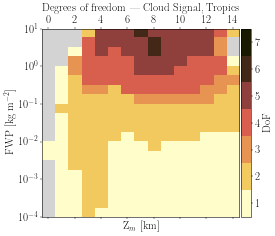

In [7]:

# ── plot ──

# create custom colormap
original_cmap = cmc.lajolla_r
num_colors = 7
colors = original_cmap(np.linspace(0, 1, num_colors))
cmap = LinearSegmentedColormap.from_list("truncated_cmap", colors, N=num_colors)

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor("lightgrey")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)

n_channels = CS_array.shape[1]
mat = ax.matshow(DoF_grid, cmap=cmap, vmin=0.5, vmax=num_colors + 0.5,
                 origin="lower", aspect="auto")
fig.colorbar(mat, cax=cax, ticks=np.arange(0, num_colors + 1), label="DoF")

ax.set_xticks(np.arange(len(x_bins) - 1)[::x_stride])
ax.set_xticklabels(x_bins[:-1][::x_stride].astype(int))

ax.set_yticks(np.array([0, 4, 8, 12, 16, 20]) - 0.5)
ax.set_yticklabels([r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$",
                    r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"])

ax.set_xlabel(x_label)
ax.set_ylabel(r"FWP [$\mathrm{kg\;m^{-2}}$]")
ax.set_title(f"Degrees of freedom — Cloud Signal, Tropics")

plt.tight_layout()
plt.savefig(f"../figures/CS_DoF_{x_var}_tropics.png",
            dpi=200, bbox_inches="tight", facecolor="white")